In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from joblib import dump, load
import os

from helpers.geometry_map import make_geometry_map, build_dist_tree_from_map
from helpers.data_transforms import load_in_data, local_phi_transformation

from tqdm import tqdm
from helpers.material_map import apply_material_map_hybrid, build_masked_datasets
from helpers.flow import build_xy_z_lookup, snap_z_to_detector_xy, build_z_lookup, snap_z_to_detector
plt.style.use("../science.mplstyle")

First we build the lookup tree that allows us to assign cell IDs to the ML samples.

In [2]:
cache_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_tree.joblib"

if os.path.exists(cache_path):
    print("Loading cached geometry tree...")
    data = load(cache_path)
    tree_map = data["tree_map"]
    cellid_layer_map = data["cellid_layer_map"]
else:



    geo_map_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_map.txt"
    
    
    collections = [
       
        "OuterTrackerBarrelCollection",     
        "OuterTrackerEndcapCollection",  
         "InnerTrackerBarrelCollection",
       "InnerTrackerEndcapCollection",
       "VertexBarrelCollection",   
      "VertexEndcapCollection",
    ]
    iid = 1
    path_to_data = f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/reco_h5/nuGun_pT_0_50_reco_{iid}.h5"
    df = pd.read_hdf(path_to_data, key="df") 
    make_geometry_map(
        df,
        collections,
        geo_map_path,
        num_events_per_col=50_000_000,
        
)
    print("Building geometry tree...")
    tree_map, cellid_layer_map = build_dist_tree_from_map(geo_map_path)

    dump(
        {
            "tree_map": tree_map,
            "cellid_layer_map": cellid_layer_map,
        },
        cache_path,
        compress=3,
    )

Loading cached geometry tree...


The cell below load in the npy flow samples. 

In [3]:
    collections = [
       
        "OuterTrackerBarrelCollection",     
        "OuterTrackerEndcapCollection",  
         "InnerTrackerBarrelCollection",
       "InnerTrackerEndcapCollection",
       "VertexBarrelCollection",   
      "VertexEndcapCollection",
    ]

feature_order_endcap = [0,4,1,2,3,6,7,8,9]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
    "sensor":8
}

feature_order_barrel =[0,4,1,2,3,6,7,8,9]
feature_indices_dict_barrel = {
   "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
     "sensor":8
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}



ZUKO_ID = "NCSF"
NAME = "cond4_philocal"
NUM_COND_INPUTS = 4
SEED = 8



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []
use_local_phi = True


In [4]:
# load in samples

all_data_dir = {}

iid = 0

path_to_data = f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/reco_h5/nuGun_pT_0_50_reco_{iid}.h5"

df = pd.read_hdf(path_to_data, key="df") 



for col_name in collections:

    print(col_name)


    df_col = df[df["collection"] == col_name]
    #df_col = df_col[df_col["inside_bounds"] == True]

    df_col = df_col.copy()

    # cylindrical coordinates
    df_col["r"] = np.sqrt(df_col["x"]**2 + df_col["y"]**2)
    df_col["phi"] = np.arctan2(df_col["y"], df_col["x"])

    # log energy
    df_col["logE"] = np.log(df_col["Edep"])

    df_col_selected = df_col[
        ["logE", "t", "r", "phi", "z", "side", "layer", "module", "sensor", "cellid0"]
    ].to_numpy()

    all_data_dir[col_name] = df_col_selected

OuterTrackerBarrelCollection
OuterTrackerEndcapCollection
InnerTrackerBarrelCollection
InnerTrackerEndcapCollection
VertexBarrelCollection
VertexEndcapCollection


For the flow samples, we need to "snap" the endcap z coordinate to the sensitive region of the detector.

OuterTrackerBarrelCollection
(6787500, 10)


/tmp/ipykernel_672490/3629695729.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[-1].legend()


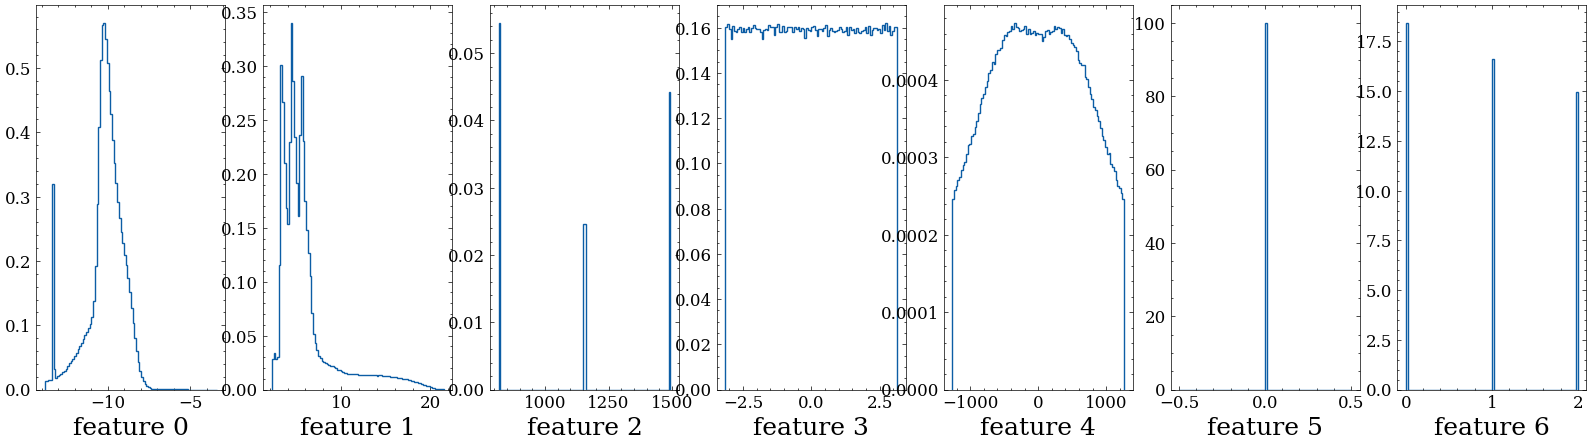

OuterTrackerEndcapCollection
(2825825, 10)


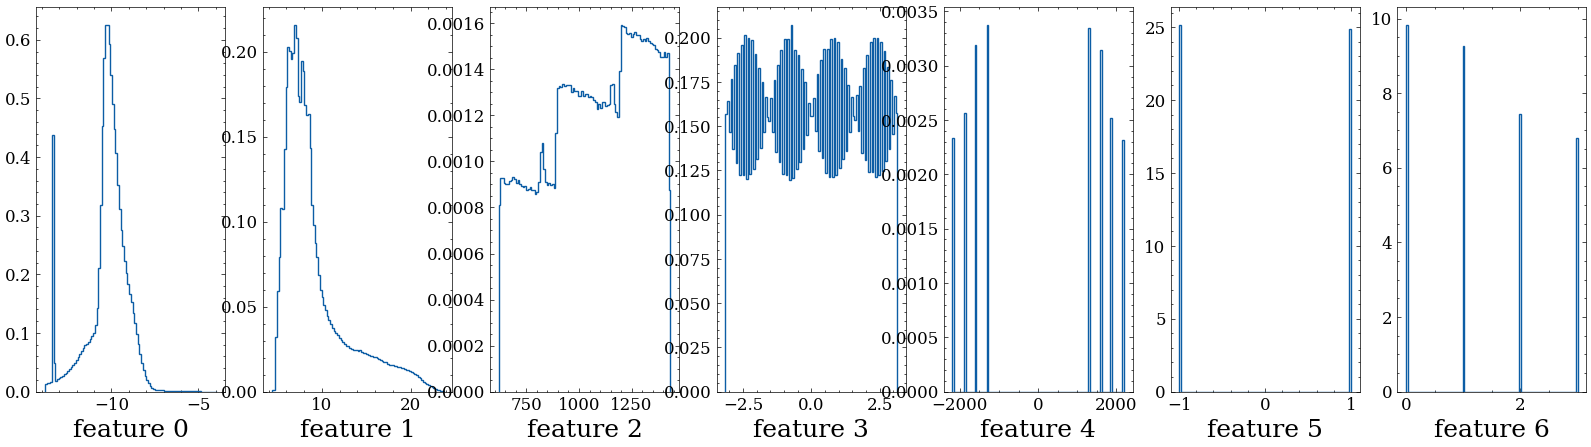

InnerTrackerBarrelCollection
(6639439, 10)


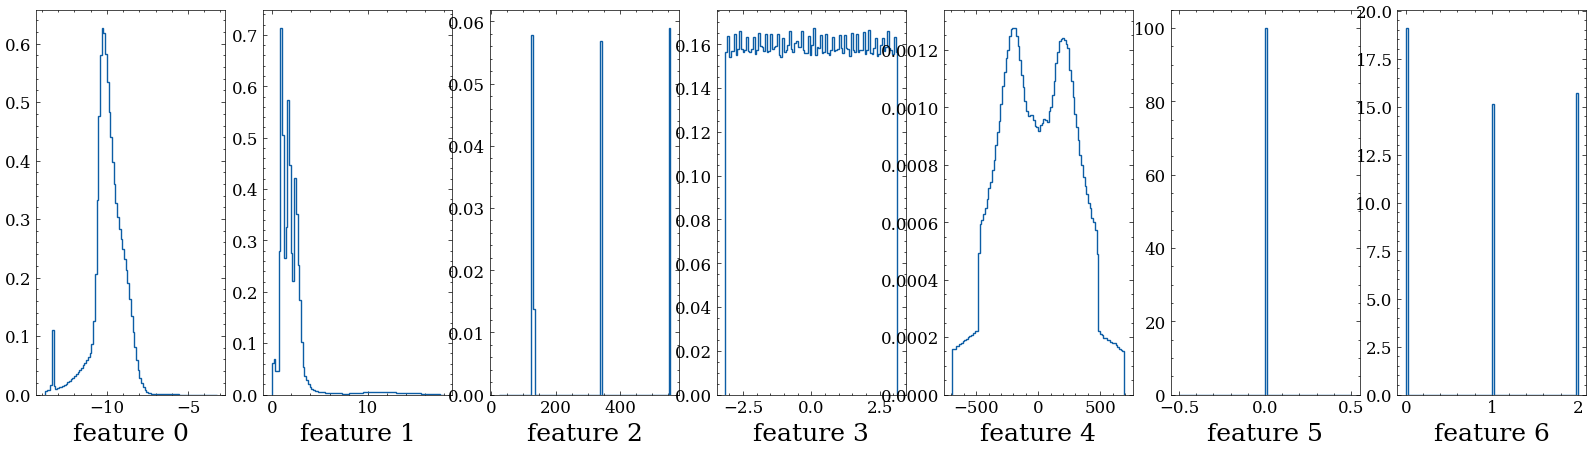

InnerTrackerEndcapCollection
(2360215, 10)


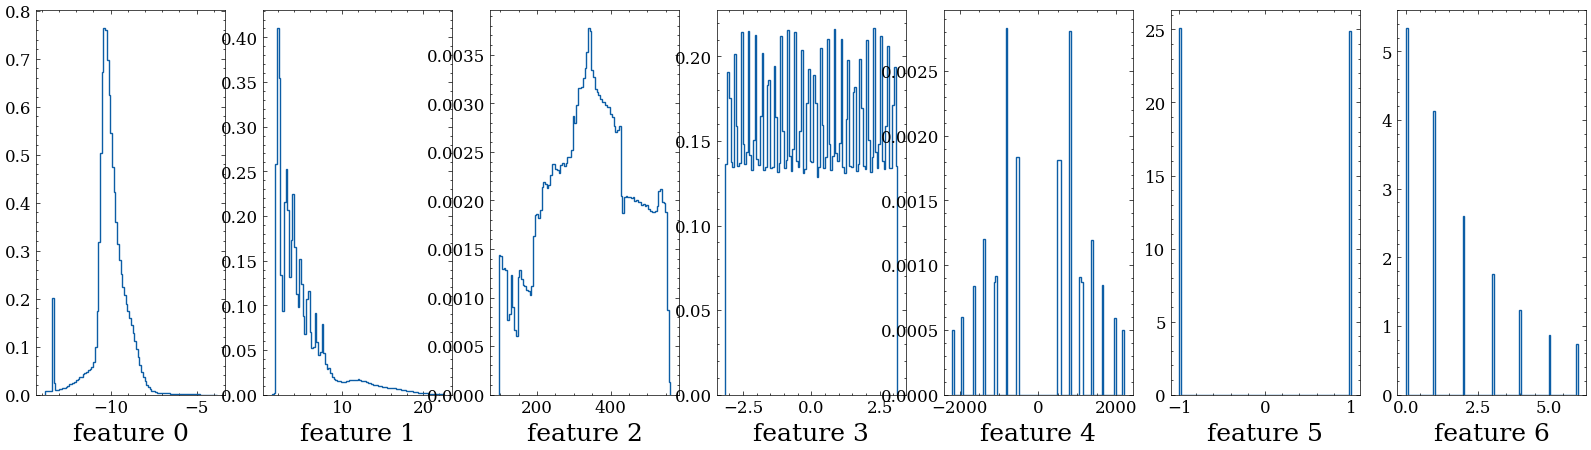

VertexBarrelCollection
(2641857, 10)


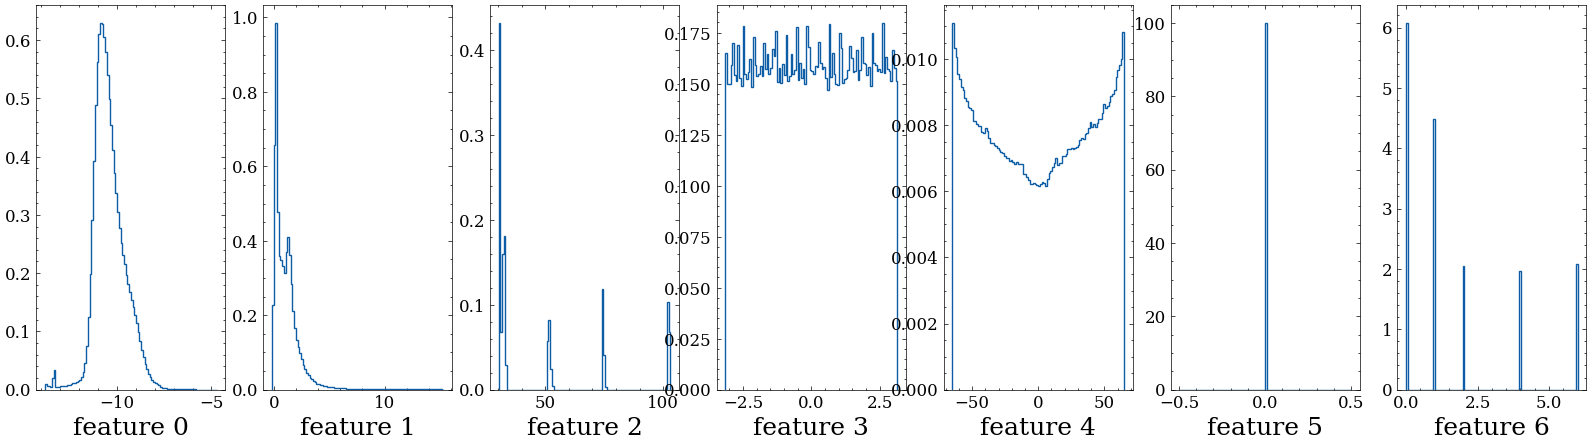

VertexEndcapCollection
(5325807, 10)


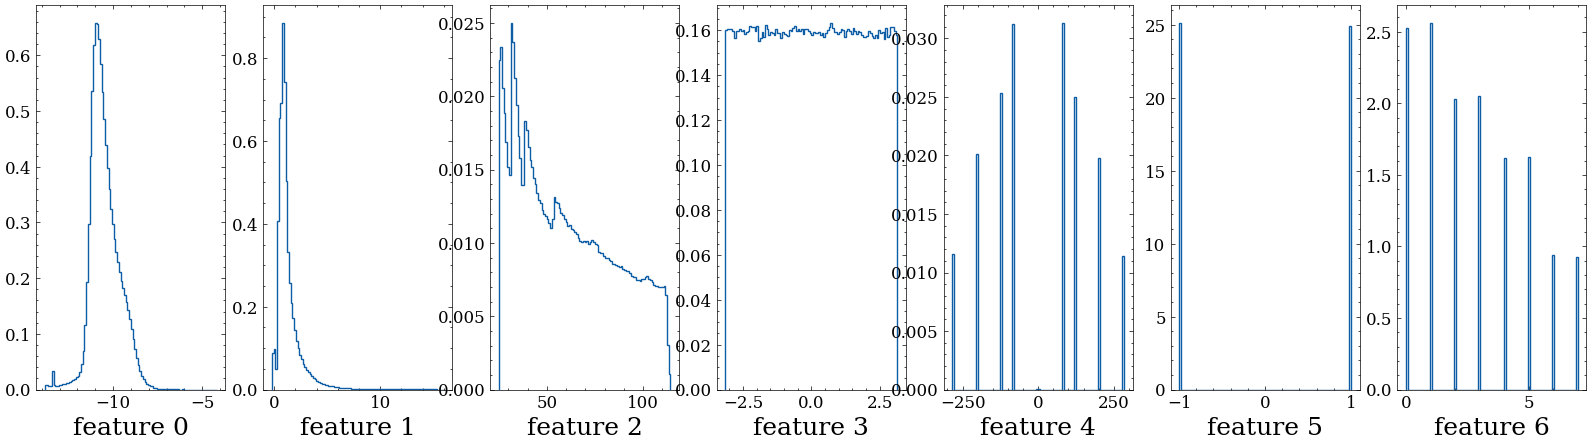

In [5]:
for col_name in collections:
    print(col_name)
    print(all_data_dir[col_name].shape)

    fig, ax = plt.subplots(1, 7, figsize = (20, 5))
    for i in range(7):
        ax[i].hist(all_data_dir[col_name][:,i], histtype = "step", bins = 100, density = True)
        ax[i].set_xlabel(f"feature {i}")
    ax[-1].legend()
    plt.show()

Now we actually assign the cell IDs to the ML BIB by sending them through the lookup tree.

In [6]:



def get_col_hits_per_layer(data):

    

    col_hits_per_layer = {col: {} for col in collections}
    dists  = {col: {} for col in collections}
    cell_ids = {col: {} for col in collections}
    valid_masks = {col: {} for col in collections}

    
    
    for col_name in collections:
    
    
        # -----------------------------
        # 1. Extract coordinates
        # -----------------------------
        r = data[col_name][:,feature_indices_dict[col_name]["r"]]
        phi = data[col_name][:,feature_indices_dict[col_name]["phi"]]
        z = data[col_name][:,feature_indices_dict[col_name]["z"]]
        x = r*np.cos(phi)
        y = r*np.sin(phi)
        
        points = np.stack([x,y,z], axis=1)   # shape (N, 3)
    
        # -----------------------------
        # 2. Mask out NaNs / infs
        # -----------------------------
        valid_mask = np.isfinite(points).all(axis=1)
        points_valid = points[valid_mask]
        valid_masks[col_name] = valid_mask
    
        # Skip if nothing valid
        if len(points_valid) == 0:
            continue
    
        # -----------------------------
        # 3. Batch KDTree query
        # -----------------------------
        dists_batch, idx_batch = tree_map[col_name].query(points_valid)
    
        # -----------------------------
        # 4. Remove invalid KDTree hits
        # -----------------------------
        valid_idx_mask = idx_batch < len(cellid_layer_map[col_name])
    
        idx_batch = idx_batch[valid_idx_mask]
        dists[col_name]  = dists_batch[valid_idx_mask]
    
        # -----------------------------
        # 5. Map to (cell_id, layer)
        # -----------------------------
        cell_layer = cellid_layer_map[col_name][idx_batch]
        layers = cell_layer[:, 1]
        cell_ids[col_name] = cell_layer[:, 0]
    
        # -----------------------------
        # 6. Count hits per layer (vectorized)
        # -----------------------------
        unique_layers, counts = np.unique(layers, return_counts=True)
    
        for layer, count in zip(unique_layers, counts):
            col_hits_per_layer[col_name][layer] = (
                col_hits_per_layer[col_name].get(layer, 0) + count
            )


    return col_hits_per_layer, dists, cell_ids, valid_masks

First apply masks to the collections, then assign cell ids

In [7]:
col_hits_per_layer_truth, dists_truth, cell_ids_truth, valid_mask = get_col_hits_per_layer(all_data_dir)



Diagnostic plot

OuterTrackerBarrelCollection 6787500
OuterTrackerEndcapCollection 2825825
InnerTrackerBarrelCollection 6639439
InnerTrackerEndcapCollection 2360215
VertexBarrelCollection 2641857
VertexEndcapCollection 5325807


/tmp/ipykernel_672490/4143670260.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


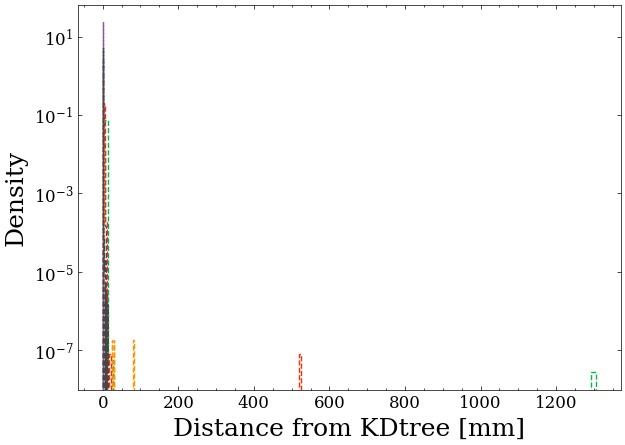

In [8]:
for key in all_data_dir.keys():
    print(key, len(all_data_dir[key]))


plt.figure()
for i, col in enumerate(collections):
    plt.hist(dists_truth[col], bins = 100, histtype = "step", density = True, linestyle = "dashed", color = f"C{i}")
plt.yscale("log")
plt.xlabel("Distance from KDtree [mm]")
plt.ylabel("Density")
plt.legend()
plt.show()


In [11]:
for col_name in collections:
    
    num_hits = len(all_data_dir[col_name])
    print(col_name)
    
    assert(num_hits == len(cell_ids_truth[col_name]))

    mismatched_hits = all_data_dir[col_name][:,-1] != cell_ids_truth[col_name]
    print(np.sum(mismatched_hits), 100.0*np.sum(mismatched_hits)/num_hits)

OuterTrackerBarrelCollection
194878 2.8711307550644567
OuterTrackerEndcapCollection
15317 0.5420363964505941
InnerTrackerBarrelCollection
65188 0.9818299407525244
InnerTrackerEndcapCollection
8182 0.346663333636978
VertexBarrelCollection
10540 0.3989617908917856
VertexEndcapCollection
17433 0.3273306749568657


More sanity checks (not important)

Randomly save out 10% of the ML BIB samples so that digitization and reconstruction run faster

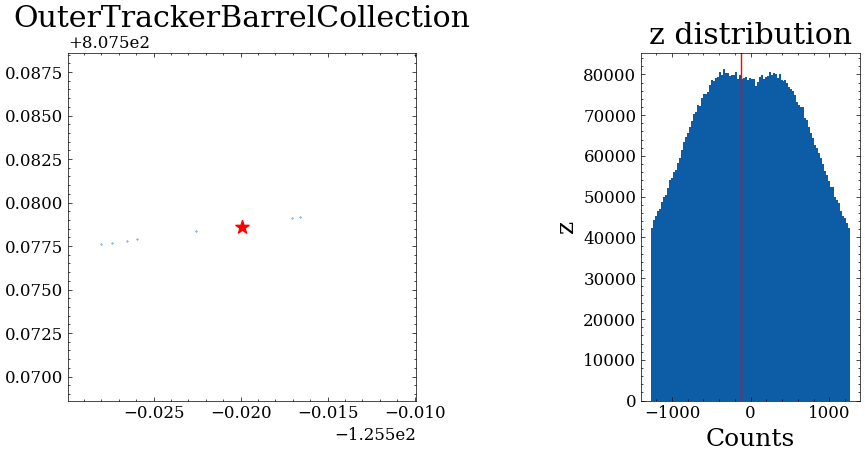

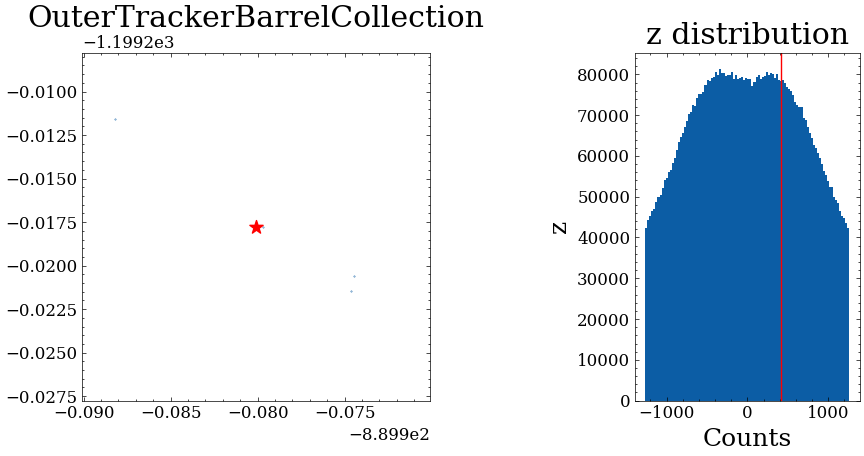

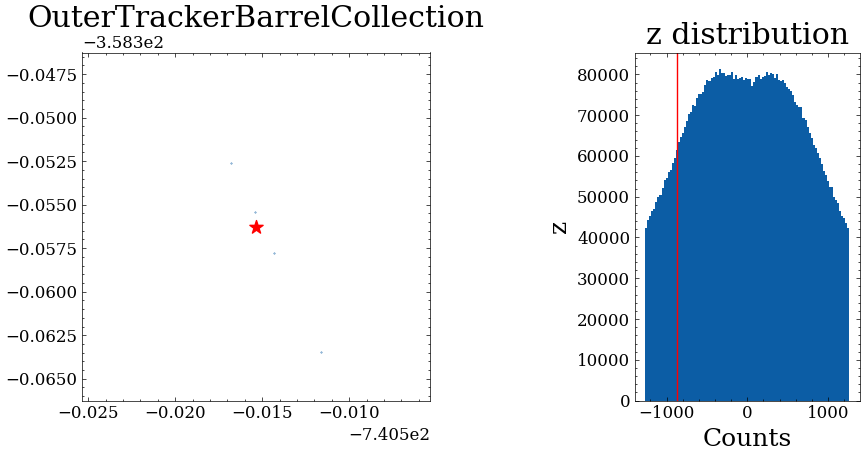

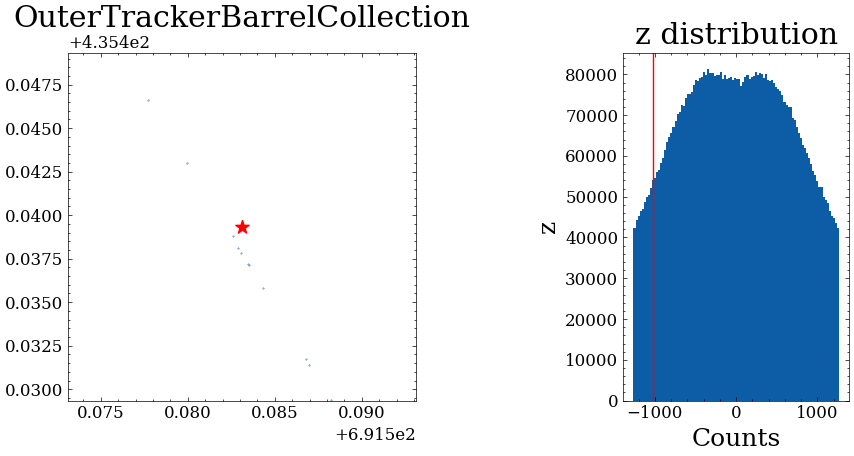

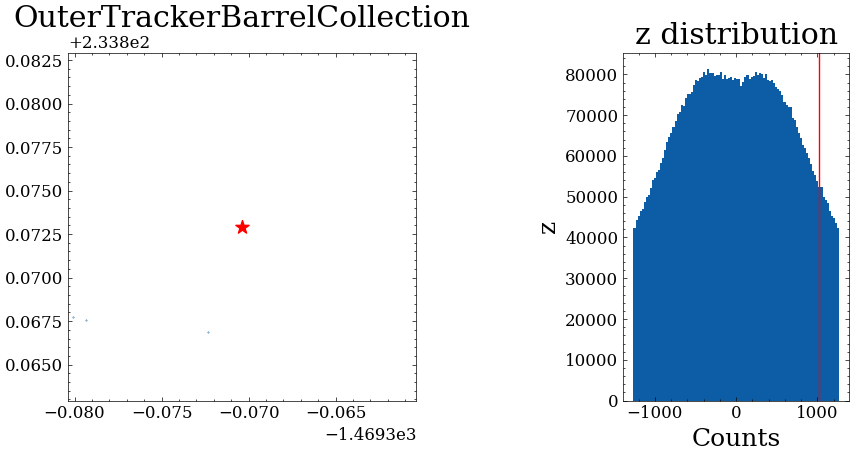

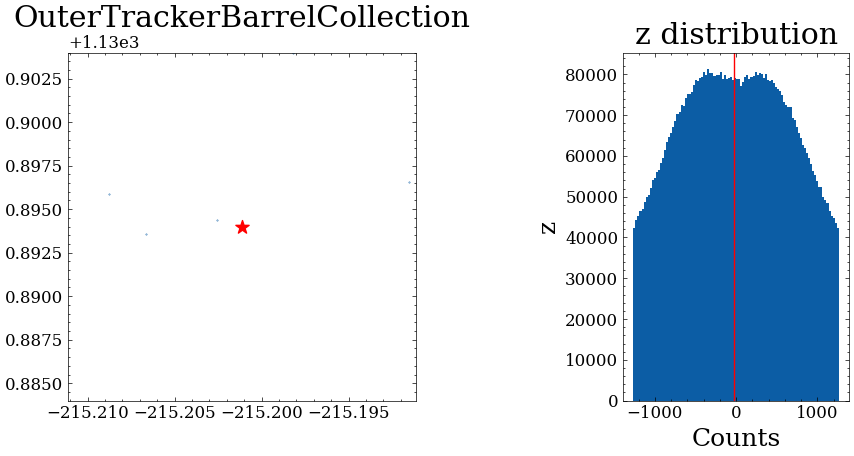

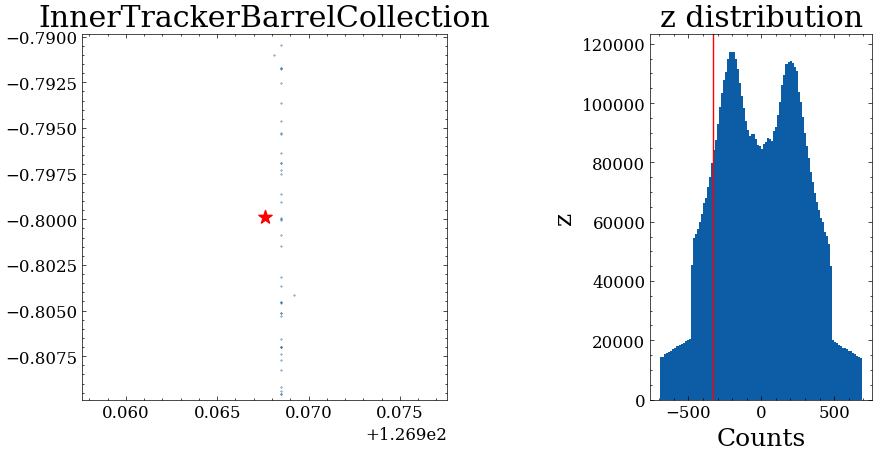

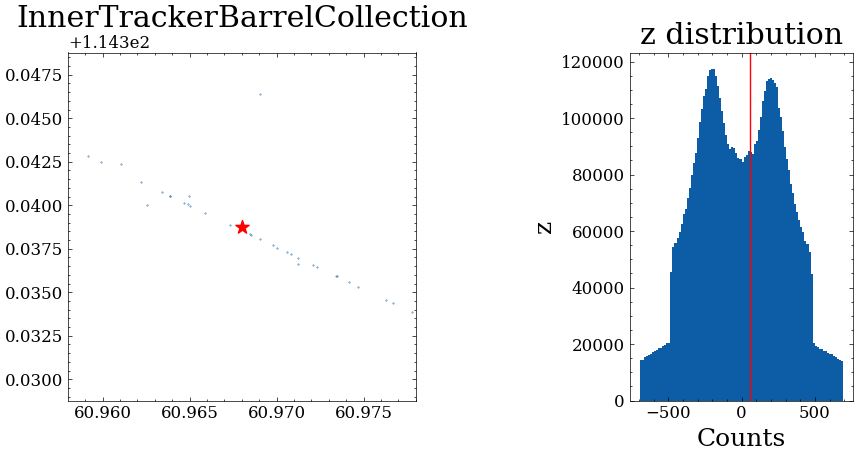

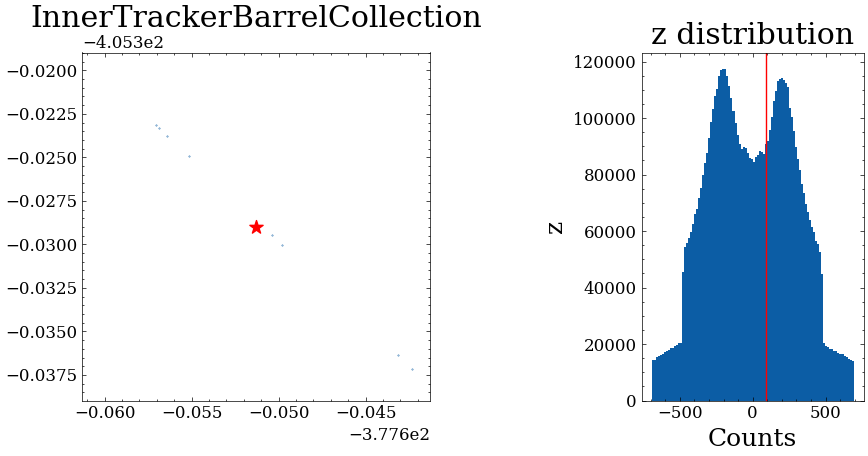

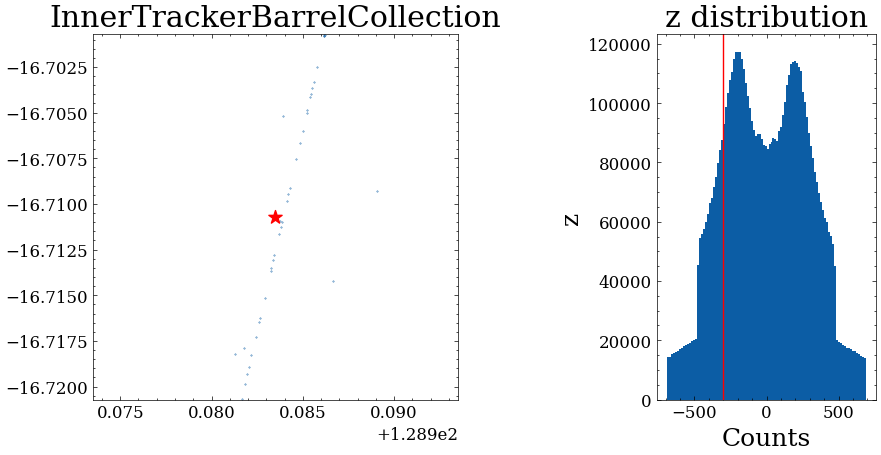

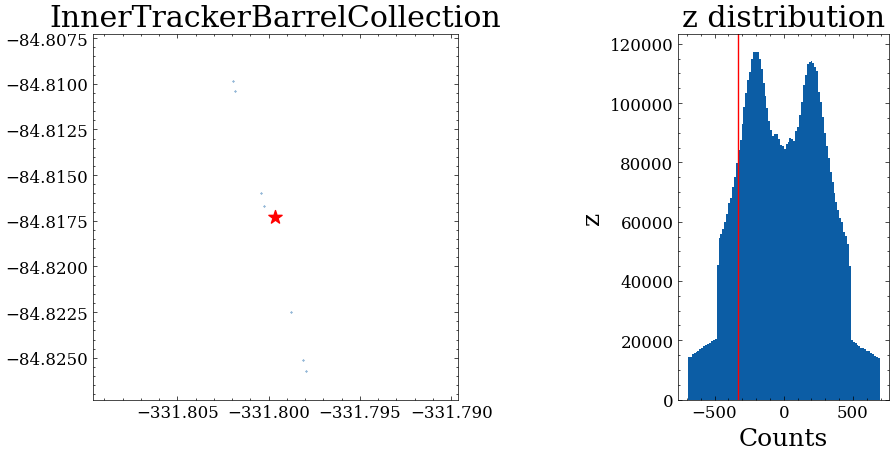

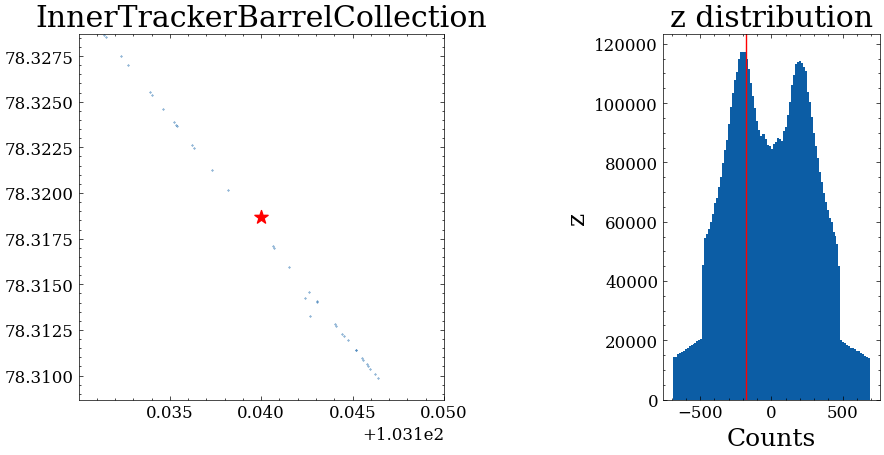

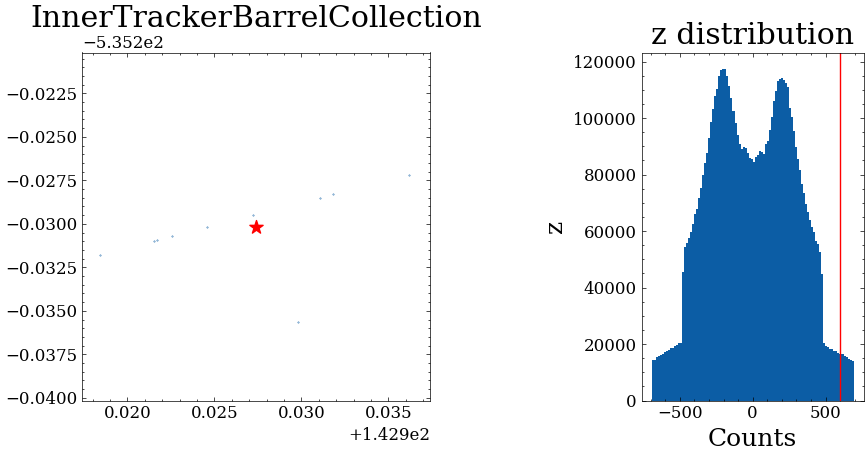

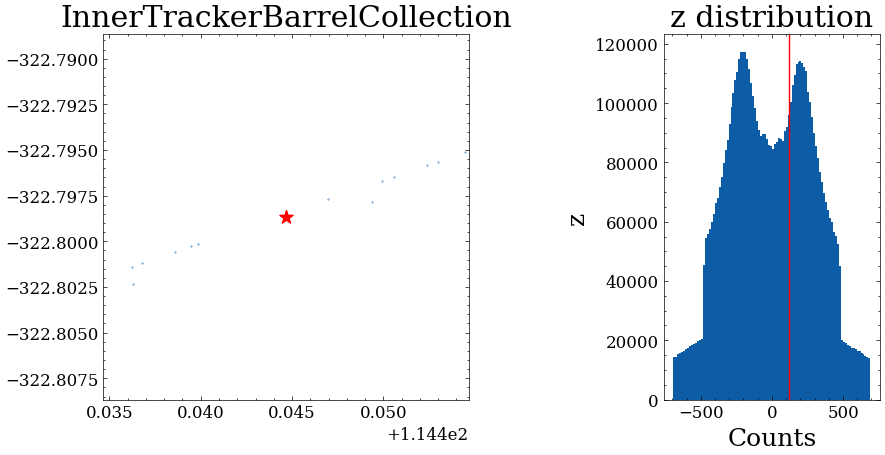

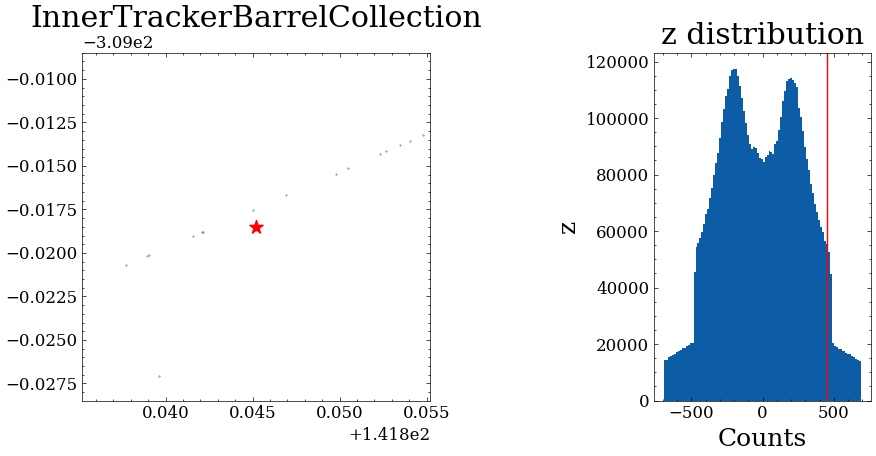

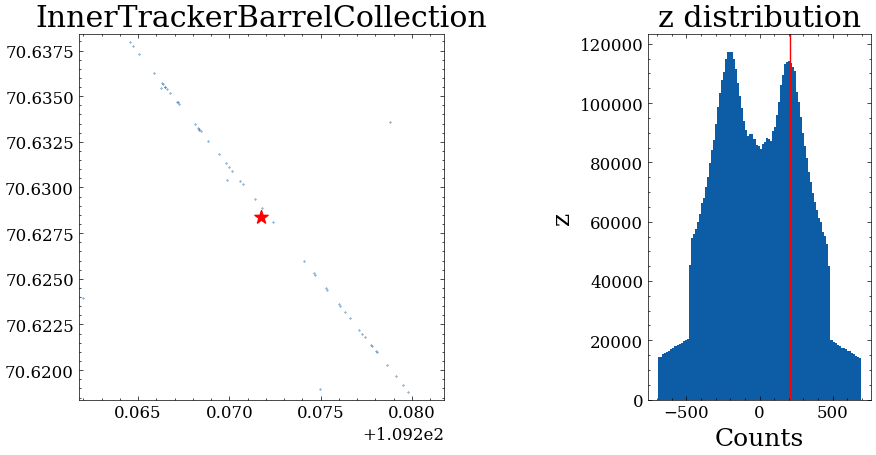

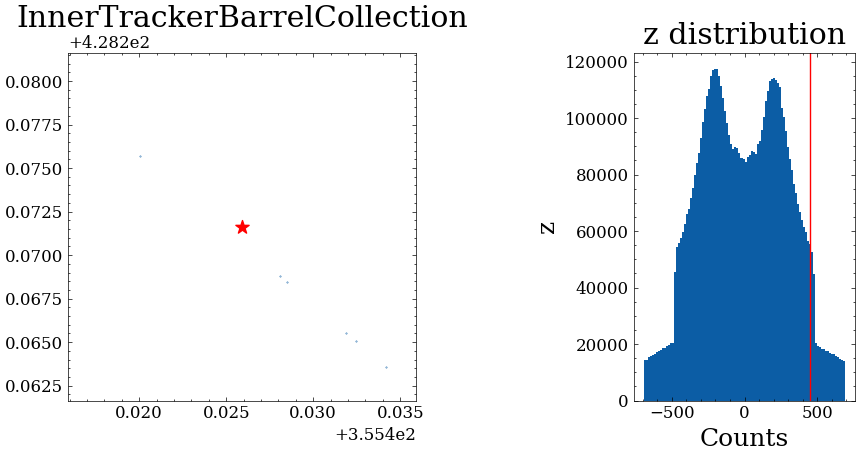

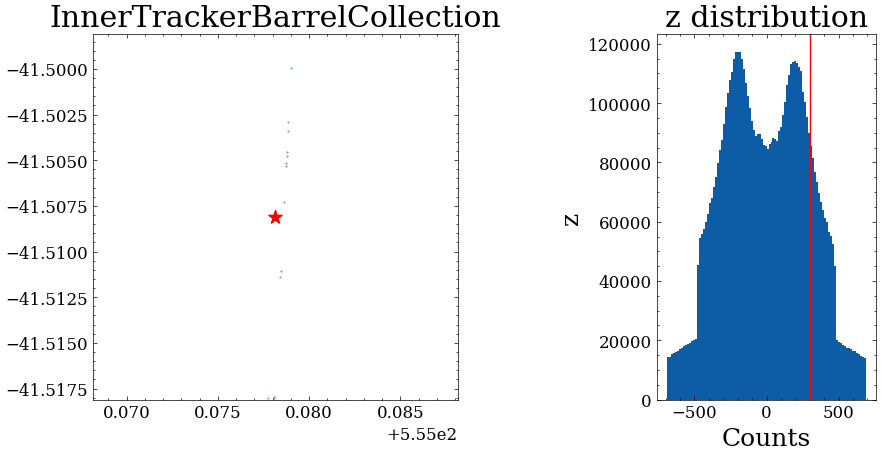

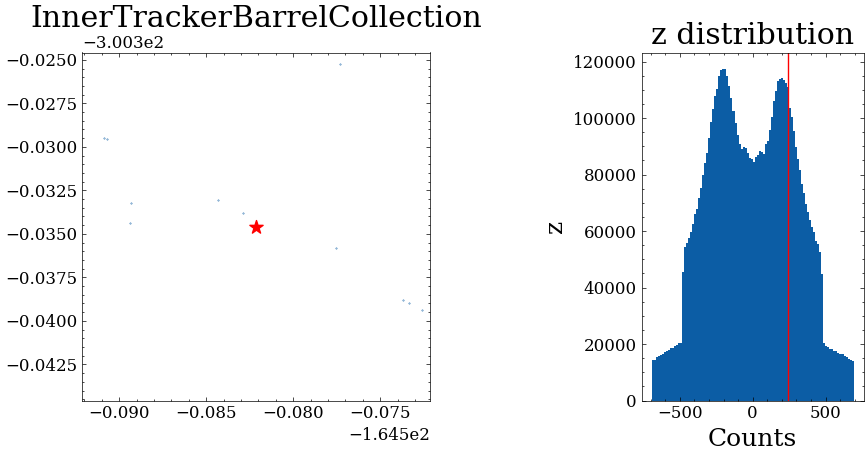

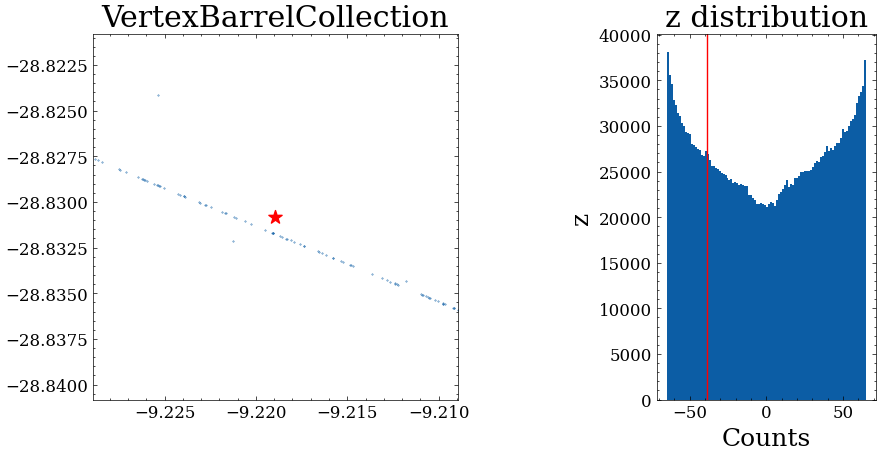

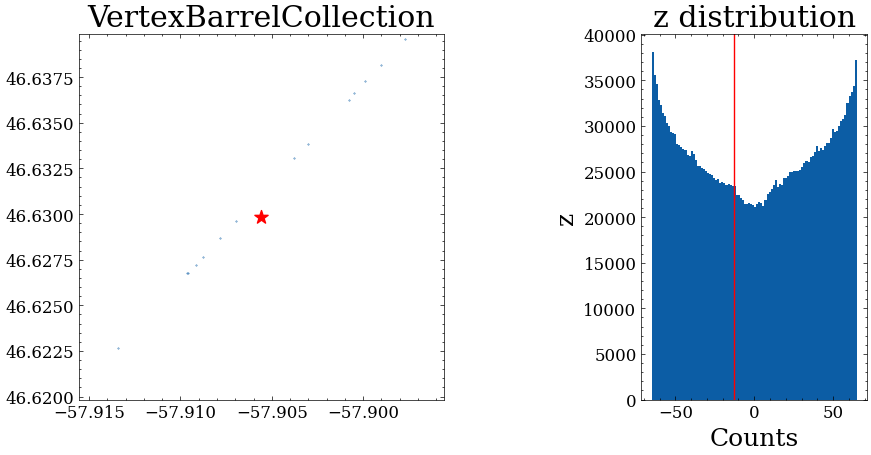

In [35]:
invalid_points = {
    "OuterTrackerBarrelCollection": [
        [-125.51990431,   807.57862102,  -120.4],
        [-889.98008472, -1199.21775481,   421.4],
        [-740.51535313,  -358.35625588,  -872.9],
        [ 691.58313008,   435.43934629, -1023.4],
        [-1469.37036221,  233.87293374,  1023.4],
        [-215.20111710, 1130.89400175,   -30.1],
    ],

    "InnerTrackerBarrelCollection": [
        [ 126.96760276,   -0.79987486, -331.1],
        [  60.96802965,  114.33877759,   60.2],
        [-377.65128755, -405.32897498,   90.3],
        [ 128.98348800,  -16.71071280, -301.0],
        [-331.79963316,  -84.81728974, -331.1],
        [ 103.14001407,   78.31868758, -180.6],
        [ 142.92739977, -535.23015523,  602.0],
        [ 114.44466902, -322.79866661,  120.4],
        [ 141.84520356, -309.01848397,  451.5],
        [ 109.27175148,   70.62838661,  210.7],
        [ 355.42592370,  428.27164129,  451.5],
        [ 555.07814113,  -41.50810610,  301.0],
        [-164.58213191, -300.33457884,  240.8],
    ],

    "VertexBarrelCollection": [
        [ -9.21893659, -28.83082228, -39.        ],
         [-57.90557822,  46.62983806, -13.        ]
    ],
}
for col_name in invalid_points.keys():

    x = all_data_dir[col_name][:, 2] * np.cos(all_data_dir[col_name][:, 3])
    y = all_data_dir[col_name][:, 2] * np.sin(all_data_dir[col_name][:, 3])
    z = all_data_dir[col_name][:, 4]

    for p in invalid_points[col_name]:

        xx, yy, zz = p

        fig, (ax1, ax2) = plt.subplots(
            1, 2, figsize=(10, 5),
            gridspec_kw={"width_ratios": [3, 1]}
        )

        dd = 0.01
        # Left: x-y scatter
        ax1.scatter(x, y, s=0.1)
        ax1.scatter(xx, yy, color="r", marker="*", s=100)
        ax1.set_xlim(xx - dd, xx + dd)
        ax1.set_ylim(yy - dd, yy + dd)
        ax1.set_title(col_name)
        ax1.set_aspect("equal")

        # Right: z histogram
        ax2.hist(z, bins=100)
        ax2.set_xlabel("Counts")
        ax2.set_ylabel("z")
        ax2.set_title("z distribution")
        ax2.axvline(zz, color = "r")

        plt.tight_layout()
        plt.show()